## To build a Linear Regression model to predict the Price using the given Housing dataset.

### `Objective:`

- Perform data preprocessing and basic EDA.
- Select appropriate numeric features.
- Train a Linear Regression model.
- Predict the Price.
- Evaluate the model using MAE, MSE, RMSE, and R² Score.

## Loading The Dataset

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Housing.csv')

In [3]:
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


## Inspecting Null Values

In [4]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

## Inspecting Duplicated Values

In [5]:
df.duplicated().sum()

np.int64(0)

## Encoding Categorical Columns

In [12]:
from sklearn.preprocessing import OneHotEncoder

In [9]:
cat_col = df.select_dtypes(include=['object', 'category']).columns

In [10]:
cat_col

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [16]:
encoder = OneHotEncoder(sparse_output=False, drop='first')

In [17]:
cat_encoded = encoder.fit_transform(df[cat_col])

In [18]:
cat_encoded

array([[1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 1., ..., 1., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 1.]], shape=(545, 8))

In [20]:
encoder.get_feature_names_out()

array(['mainroad_yes', 'guestroom_yes', 'basement_yes',
       'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype=object)

In [21]:
cat_encoded = pd.DataFrame(cat_encoded, columns=encoder.get_feature_names_out())

In [22]:
cat_encoded

,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
540,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
541,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
542,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
543,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Scaling Numerical Columns

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [30]:
numerical_col = df.drop("price",axis=1)
numerical_col = numerical_col.select_dtypes(include=['int64', 'float64']).columns
numerical_col

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

In [33]:
numerical_scaled = scaler.fit_transform(df[numerical_col])

In [34]:
numerical_scaled

array([[ 1.04672629,  1.40341936,  1.42181174,  1.37821692,  1.51769249],
       [ 1.75700953,  1.40341936,  5.40580863,  2.53202371,  2.67940935],
       [ 2.21823241,  0.04727831,  1.42181174,  0.22441013,  1.51769249],
       ...,
       [-0.70592066, -1.30886273, -0.57018671, -0.92939666, -0.80574124],
       [-1.03338891,  0.04727831, -0.57018671, -0.92939666, -0.80574124],
       [-0.5998394 ,  0.04727831, -0.57018671,  0.22441013, -0.80574124]],
      shape=(545, 5))

In [35]:
scaler.get_feature_names_out()

array(['area', 'bedrooms', 'bathrooms', 'stories', 'parking'],
      dtype=object)

In [36]:
numerical_scaled = pd.DataFrame(numerical_scaled, columns=scaler.get_feature_names_out())

In [37]:
numerical_scaled

,area,bedrooms,bathrooms,stories,parking
0,1.046726,1.403419,1.421812,1.378217,1.517692
1,1.757010,1.403419,5.405809,2.532024,2.679409
2,2.218232,0.047278,1.421812,0.224410,1.517692
3,1.083624,1.403419,1.421812,0.224410,2.679409
4,1.046726,1.403419,-0.570187,0.224410,1.517692
...,...,...,...,...,...
540,-0.991879,-1.308863,-0.570187,-0.929397,1.517692
541,-1.268613,0.047278,-0.570187,-0.929397,-0.805741
542,-0.705921,-1.308863,-0.570187,-0.929397,-0.805741
543,-1.033389,0.047278,-0.570187,-0.929397,-0.805741


## Merging Categorical & Numerical Columns

In [38]:
df = pd.concat([numerical_scaled, cat_encoded, df['price']], axis=1)

In [39]:
df

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished,price
0,1.046726,1.403419,1.421812,1.378217,1.517692,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,13300000
1,1.757010,1.403419,5.405809,2.532024,2.679409,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,12250000
2,2.218232,0.047278,1.421812,0.224410,1.517692,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,12250000
3,1.083624,1.403419,1.421812,0.224410,2.679409,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,12215000
4,1.046726,1.403419,-0.570187,0.224410,1.517692,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,11410000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,-0.991879,-1.308863,-0.570187,-0.929397,1.517692,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1820000
541,-1.268613,0.047278,-0.570187,-0.929397,-0.805741,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1767150
542,-0.705921,-1.308863,-0.570187,-0.929397,-0.805741,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1750000
543,-1.033389,0.047278,-0.570187,-0.929397,-0.805741,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1750000


## Visualizing

In [40]:
import matplotlib.pyplot as plt

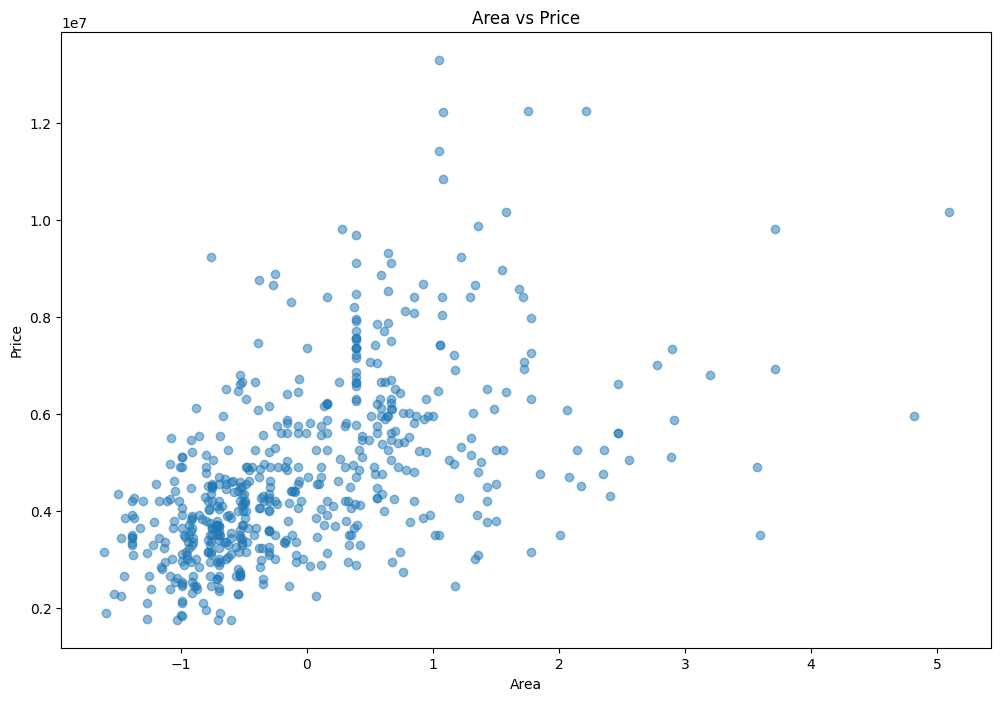

In [42]:
plt.figure(figsize=(12, 8))
plt.scatter(df['area'], df['price'], alpha=0.5)
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

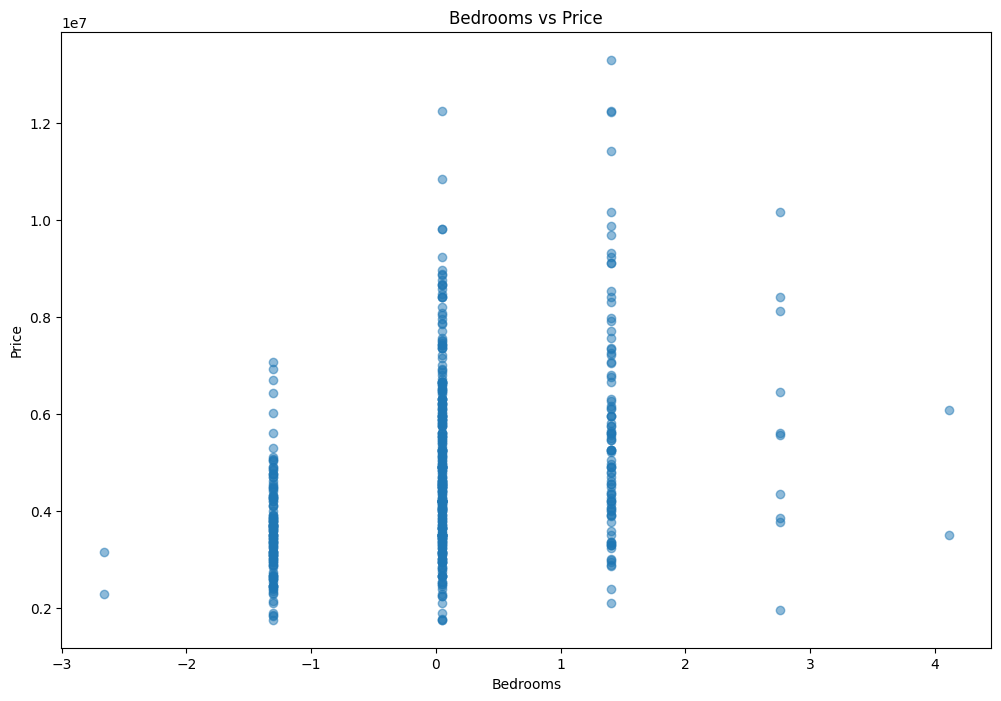

In [45]:
plt.figure(figsize=(12, 8))
plt.scatter(df['bedrooms'], df['price'], alpha=0.5)
plt.title('Bedrooms vs Price')
plt.xlabel('Bedrooms')
plt.ylabel('Price')
plt.show()

## Importing Dependencies For Model

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error, root_mean_squared_error

## Splitting the dataset into features and target variable

In [47]:
X = df.drop('price', axis=1)
y = df['price']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Training Our Linear Model

In [49]:
model = LinearRegression()

In [50]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
y_pred = model.predict(X_test)

## Evaluating Model

In [52]:
mean_squared_error(y_test, y_pred)

1754318687330.6685

In [53]:
mean_absolute_error(y_test, y_pred)

970043.4039201643

In [54]:
root_mean_squared_error(y_test, y_pred)

1324506.9600914405

In [55]:
r2_score(y_test, y_pred)

0.6529242642153175

## **Evaluation Results:**
- **R2 score : 65.2%**
- **MAE : 970043.40**
- **MSE : 1754318687330.66**
- **RMSE : 1324506.96**